<a href="https://colab.research.google.com/github/muhammad-usman-tech/data-analysis-tasks/blob/main/lab_19(B)_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

# print("Shape:", df.shape)
# print("\nColumns:", df.columns.tolist())
# print("\nData Types:")
# print(df.dtypes)
# print("\nMissing Values:")
# print(df.isnull().sum())
# print("\nFirst 5 rows:")
# df.head()
# Search and Filter
print("Top 10 highest fare passengers:")
print(df.nlargest(10, 'Fare')[['Name', 'Pclass', 'Fare', 'Survived']])

print("\nFiltered — Female passengers who survived:")
female_survived = df[(df['Sex'] == 'female') & (df['Survived'] == 1)]
print(f"Count: {len(female_survived)}")
print(female_survived[['Name', 'Age', 'Pclass']].head(5))

print("\nFiltered — 1st class passengers:")
first_class = df[df['Pclass'] == 1]
print(f"Count: {len(first_class)}")

# Unique values
print("\nUnique values in Sex:", df['Sex'].unique())
print("Unique values in Pclass:", df['Pclass'].unique())
print("Unique values in Embarked:", df['Embarked'].unique())

print("\nValue counts — Sex:")
print(df['Sex'].value_counts())

print("\nValue counts — Pclass:")
print(df['Pclass'].value_counts())

print("\nValue counts — Embarked:")
print(df['Embarked'].value_counts())
# All aggregation functions
print("=" * 50)
print("AGGREGATION ANALYSIS")
print("=" * 50)

# Overall statistics
print("\n1. DESCRIBE — Full Summary:")
print(df[['Age', 'Fare', 'SibSp', 'Parch']].describe())

# Sum
print("\n2. SUM:")
print(f"Total Fare collected: ${df['Fare'].sum():.2f}")
print(f"Total Survivors: {df['Survived'].sum()}")

# Max and Min
print("\n3. MAX and MIN:")
print(f"Oldest passenger: {df['Age'].max()} years")
print(f"Youngest passenger: {df['Age'].min()} years")
print(f"Highest fare: ${df['Fare'].max():.2f}")
print(f"Lowest fare: ${df['Fare'].min():.2f}")

# Mean
print("\n4. MEAN:")
print(f"Average age: {df['Age'].mean():.2f}")
print(f"Average fare: ${df['Fare'].mean():.2f}")

# Median
print("\n5. MEDIAN:")
print(f"Median age: {df['Age'].median()}")
print(f"Median fare: ${df['Fare'].median():.2f}")

# Mode
print("\n6. MODE:")
print(f"Most common age: {df['Age'].mode()[0]}")
print(f"Most common fare: ${df['Fare'].mode()[0]:.2f}")

# Std Dev
print("\n7. STANDARD DEVIATION:")
print(f"Age std dev: {df['Age'].std():.2f}")
print(f"Fare std dev: ${df['Fare'].std():.2f}")

# Count
print("\n8. COUNT:")
print(f"Total passengers: {df['PassengerId'].count()}")
print(f"Age count (non-null): {df['Age'].count()}")

# GroupBy aggregations
print("\n9. SURVIVAL RATE BY CLASS:")
survival_class = df.groupby('Pclass')['Survived'].agg(
    Count='count',
    Survived_Sum='sum',
    Survival_Rate=lambda x: f"{x.mean()*100:.1f}%"
)
print(survival_class)

print("\n10. FARE STATS BY CLASS:")
fare_class = df.groupby('Pclass')['Fare'].agg(
    Mean='mean',
    Median='median',
    Max='max',
    Min='min',
    Std='std'
).round(2)
print(fare_class)

Top 10 highest fare passengers:
                                      Name  Pclass      Fare  Survived
258                       Ward, Miss. Anna       1  512.3292         1
679     Cardeza, Mr. Thomas Drake Martinez       1  512.3292         1
737                 Lesurer, Mr. Gustave J       1  512.3292         1
27          Fortune, Mr. Charles Alexander       1  263.0000         0
88              Fortune, Miss. Mabel Helen       1  263.0000         1
341         Fortune, Miss. Alice Elizabeth       1  263.0000         1
438                      Fortune, Mr. Mark       1  263.0000         0
311             Ryerson, Miss. Emily Borie       1  262.3750         1
742  Ryerson, Miss. Susan Parker "Suzette"       1  262.3750         1
118               Baxter, Mr. Quigg Edmond       1  247.5208         0

Filtered — Female passengers who survived:
Count: 233
                                                Name   Age  Pclass
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0       

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


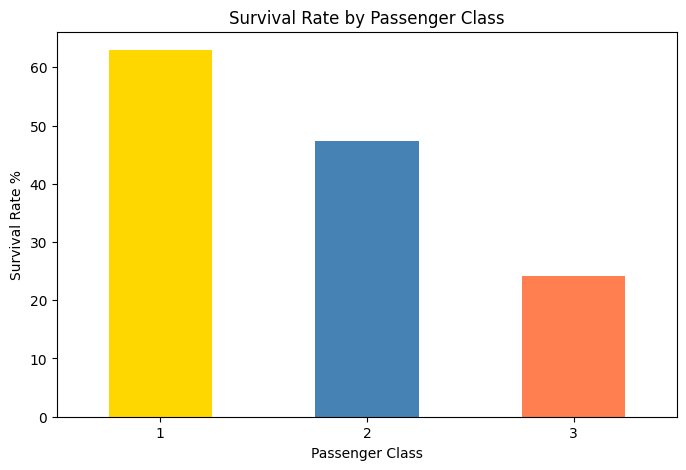

In [5]:
survival_rate = df.groupby('Pclass')['Survived'].mean() * 100
print(survival_rate)
plt.figure(figsize=(8, 5))
survival_rate.plot(kind='bar', color=['gold', 'steelblue', 'coral'])
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate %')
plt.xticks(rotation=0)
plt.show()

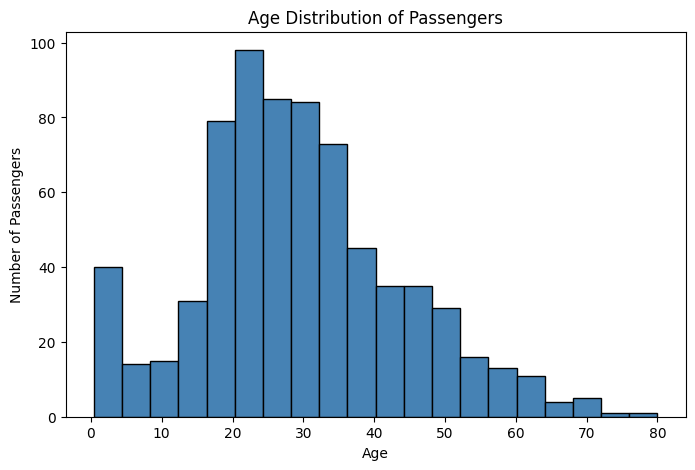

In [6]:
plt.figure(figsize=(8, 5))
df['Age'].dropna().plot(kind='hist', bins=20,
                        color='steelblue', edgecolor='black')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

<Figure size 800x500 with 0 Axes>

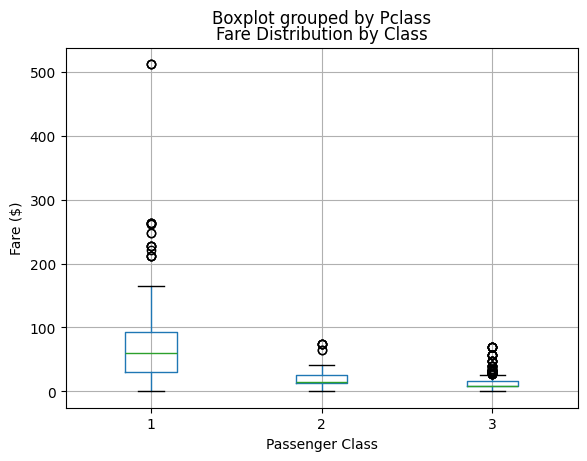

In [7]:
plt.figure(figsize=(8, 5))
df.boxplot(column='Fare', by='Pclass')
plt.title('Fare Distribution by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.show()

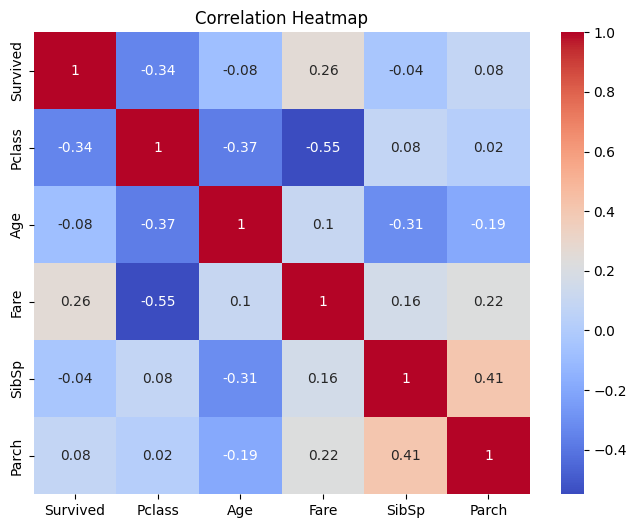

In [13]:
plt.figure(figsize=(8, 6))
numeric_cols = df[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']]
sns.heatmap(numeric_cols.corr().round(2), annot=True, cmap='coolwarm' )
plt.title('Correlation Heatmap')
plt.show()

# ***Task 2 ***

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
Year                   float64
dtype: object


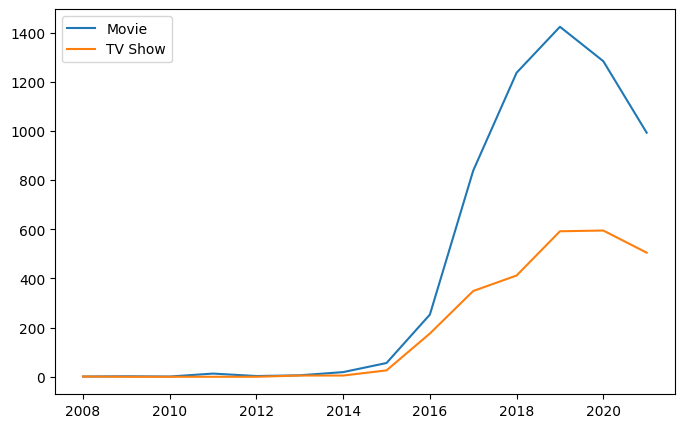

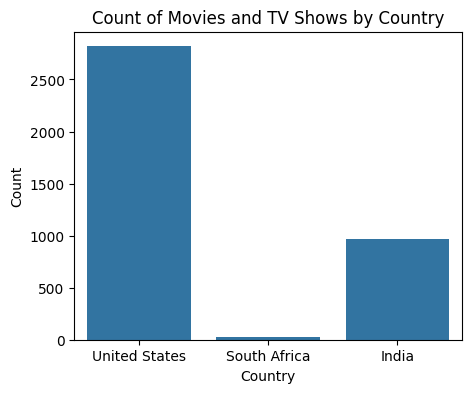

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('netflix_titles.csv')
df.shape


df['date_added']=pd.to_datetime(df['date_added'],format='mixed')
df['Year']=df['date_added'].dt.year
df['Year']
print(df.dtypes)


# line plot for the see the trend of the movies and the tv shows over the year
plt.figure(figsize=(8, 5))
selected=df.groupby('Year')['type'].value_counts().unstack(fill_value=0)
plt.plot(selected.index,selected.values)
plt.legend(selected.columns)
plt.show()

# count plot for compairing the specific countries over their counts
plt.figure(figsize=(5, 4))
new_df = df[df['country'].isin(['United States', 'South Africa', 'India'])]
sns.countplot(x='country',data=new_df)
plt.title('Count of Movies and TV Shows by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()


## ***Task 6 ***

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('StudentsPerformance.csv')
df.shape
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


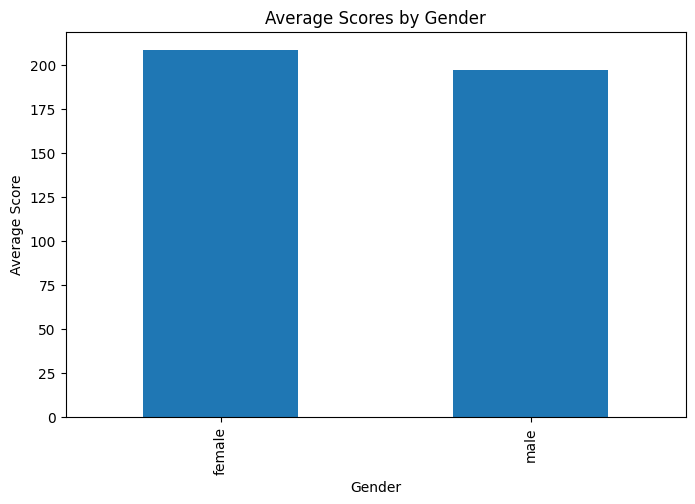

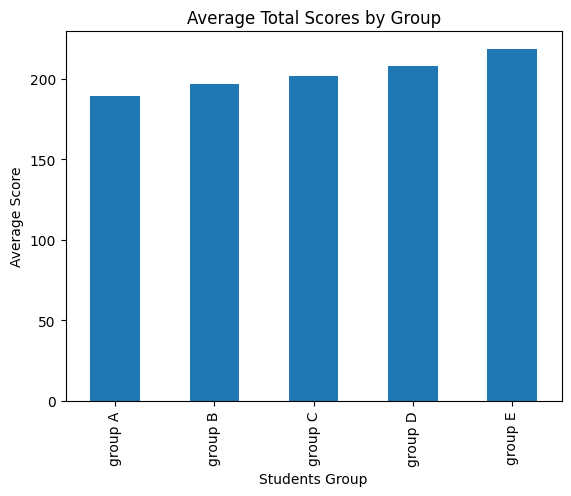

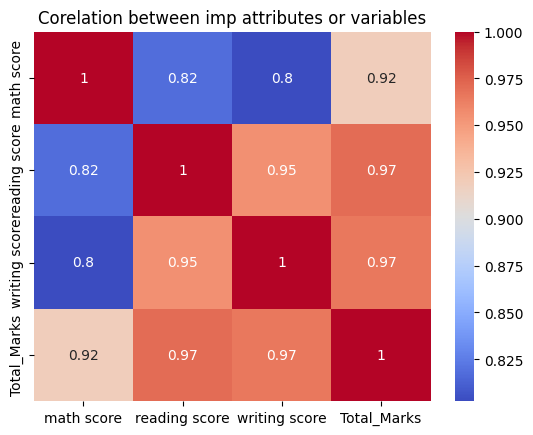

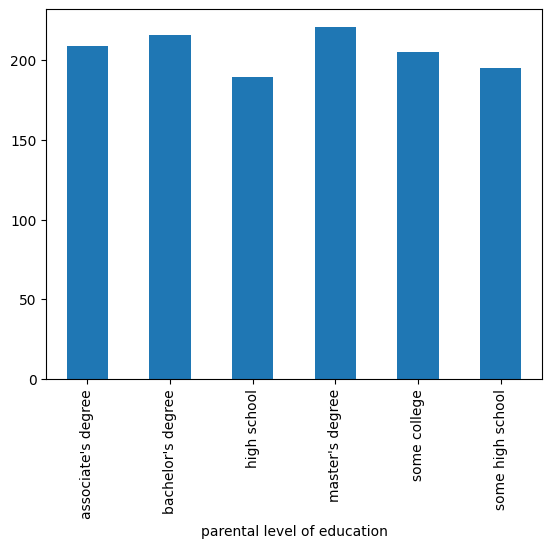

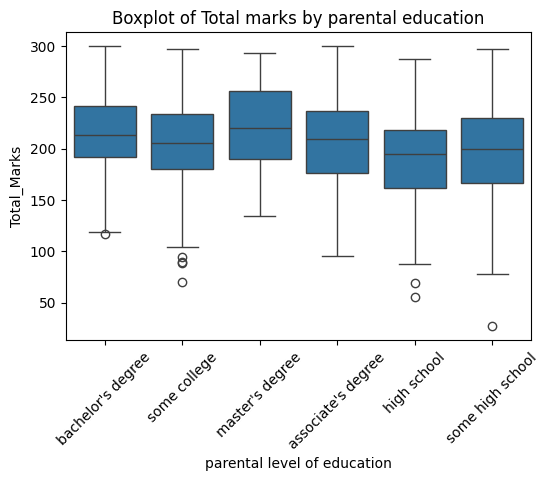

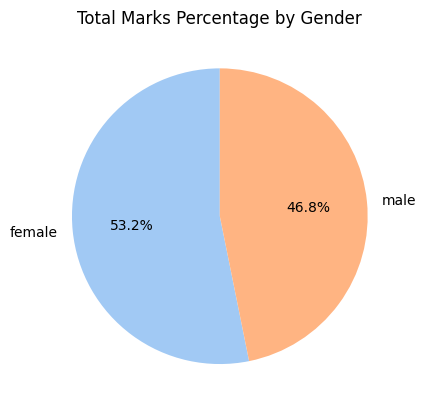

In [89]:
# bar , showing total avg by gender
df['Total_Marks']=df['math score']+df['reading score']+df['writing score']
bar_data=df.groupby('gender')['Total_Marks'].mean()
bar_data
plt.figure(figsize=(8,5))
bar_data.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.title('Average Scores by Gender')
plt.show()

# 2 bar, avg score by gropup
bar=df.groupby('race/ethnicity')['Total_Marks'].mean()
bar.plot(kind='bar')
plt.xlabel('Students Group')
plt.ylabel('Average Score')
plt.title('Average Total Scores by Group')
plt.show()

#  heatmap,showing corelation btw parental level of education,test preparation coursemath score	reading score	writing scoreand Total score
df_new=df[['math score','reading score','writing score','Total_Marks']]
sns.heatmap(df_new.corr(),annot=True,cmap='coolwarm')
plt.title('Corelation between imp attributes or variables')
plt.show()


# 4 bar, avg score by parental level of education
df_paren=df.groupby('parental level of education')['Total_Marks'].mean()
df_paren.plot(kind='bar')
plt.show()

# 5 boxplot for level of education of parents
plt.figure(figsize=(6,4))
sns.boxplot(x='parental level of education',y='Total_Marks',data=df)
plt.title('Boxplot of Total marks by parental education')
plt.xticks(rotation=45)
plt.show()


# 6 pie chart for the total marks percent by gender
gender_marks = df.groupby('gender')['Total_Marks'].sum()
plt.pie(gender_marks,labels=gender_marks.index,autopct='%1.1f%%',startangle=90,colors=sns.color_palette('pastel')[0:2])
plt.title('Total Marks Percentage by Gender')
plt.show()

